In [ ]:
import logging

from scipy import sparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import os
import seaborn as sns
import time
from sklearn.model_selection import ParameterGrid

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import umap as up

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from tools import plot_3D, plot_the_PCA_interval, plot_clusters

os.environ["MKL_THREADING_LAYER"] = "GNU"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
RANDOM_SEED = 42

In [2]:
X = sparse.load_npz("../datasets/clusterization/train.npz")
M, N = X.shape
# масштабируем
scaler = RobustScaler(with_centering=False)
X_scaled = scaler.fit_transform(X)
# PCA
pca_new = PCA(n_components=40)
X_embedded_pca = pca_new.fit_transform(X_scaled)

### GaussianMixture


Text(0, 0.5, 'number of clusters')

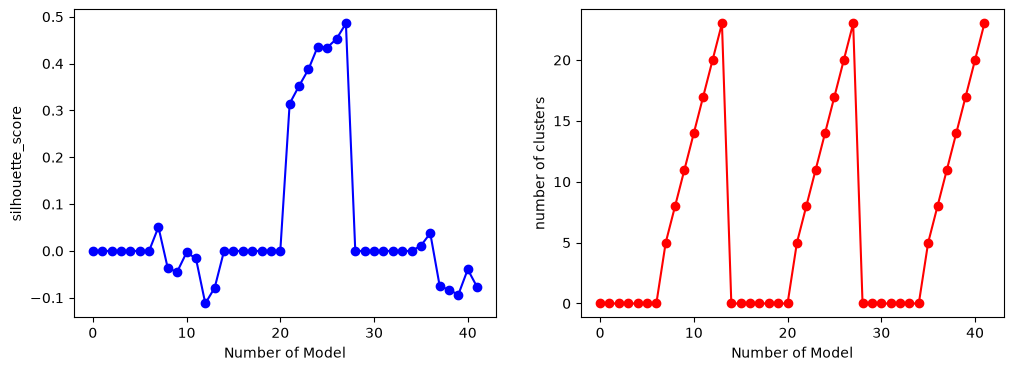

In [4]:
from sklearn.mixture import GaussianMixture


struct = time.localtime(time.time())
os.makedirs("logs", exist_ok=True)
file_name = f"logs/tunning_GaussianMixture_{time.strftime('%d_%m_%Y_%H-%M', struct)}.log"

logger = logging.getLogger("GaussianMixture")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

file_handler = logging.FileHandler(file_name, mode="w", encoding="utf-8")
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))

logger.addHandler(file_handler)

silhouette_hist = []
number_of_clusters_hist = []

param_grid = {'n_components': [5, 8, 11, 14, 17, 20, 23], 
              'covariance_type': ['full', 'tied', 'diag'], 
              'init_params': [None, 'k-means++']
}


model_num = -1
start_time = time.time()
for params in ParameterGrid(param_grid):
    model_num += 1
    logger.info("="*40 + f"MODEL #{model_num}" + "="*40)
    logger.info(f"params: {params}")

    try:
        labels = GaussianMixture(**params).fit_predict(X_embedded_pca)
    except Exception:
        logger.info(f"uncompatble params: {params}")
        silhouette_hist.append(0)
        number_of_clusters_hist.append(0)
        continue

    slt_score = silhouette_score(X_embedded_pca, labels)
    silhouette_hist.append(slt_score)
    number_of_clusters_hist.append(np.unique(labels).size)
    logger.info(f"silhouette_score: {slt_score}")
    class_counts = dict(zip(*np.unique(labels, return_counts=True)))
    logger.info(f"number of the clusters: {np.unique(labels).size}")
    logger.info(f"Clusers structure: {class_counts}")
    logger.info('Clusters found by {}'.format(str(GaussianMixture.__name__)))
    logger.info('Clustering took {:.2f} s'.format(time.time() - start_time))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(silhouette_hist, marker='o', color="blue")
ax1.set_xlabel('Number of Model')
ax1.set_ylabel('silhouette_score')

ax2.plot(number_of_clusters_hist, marker='o', color="red")
ax2.set_xlabel('Number of Model')
ax2.set_ylabel('number of clusters')


### AgglomerativeClustering Tunning

Text(0, 0.5, 'silhouette_score')

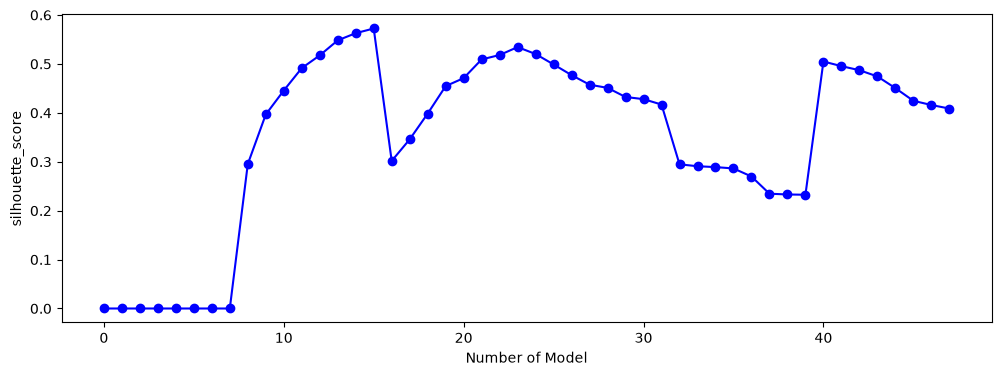

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import ParameterGrid


struct = time.localtime(time.time())
os.makedirs("logs", exist_ok=True)
file_name = f"logs/tunning_AgglomerativeClustering_{time.strftime('%d_%m_%Y_%H-%M', struct)}.log"

logger = logging.getLogger("AgglomerativeTuning")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

file_handler = logging.FileHandler(file_name, mode="w", encoding="utf-8")
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))

logger.addHandler(file_handler)

silhouette_hist = []

param_grid = {'n_clusters': [5, 9, 14, 20, 24, 32, 36, 40], 
              'linkage': ['ward', 'average', 'single'], 
              'metric': ['cosine', 'euclidean']
}


model_num = -1
start_time = time.time()
for params in ParameterGrid(param_grid):
    model_num += 1
    logger.info("="*40 + f"MODEL #{model_num}" + "="*40)
    logger.info(f"params: {params}")

    try:
        labels = AgglomerativeClustering(**params).fit_predict(X_embedded_pca)
    except Exception:
        logger.info(f"uncompatble params: {params}")
        silhouette_hist.append(0)
        continue

    slt_score = silhouette_score(X_embedded_pca, labels)
    silhouette_hist.append(slt_score)
    logger.info(f"silhouette_score: {slt_score}")
    class_counts = dict(zip(*np.unique(labels, return_counts=True)))
    logger.info(f"number of the clusters: {np.unique(labels).size}")
    logger.info(f"Clusers structure: {class_counts}")
    logger.info('Clusters found by {}'.format(str(AgglomerativeClustering.__name__)))
    logger.info('Clustering took {:.2f} s'.format(time.time() - start_time))


fig, (ax1) = plt.subplots(1, 1, figsize=(12, 4))

ax1.plot(silhouette_hist, marker='o', color="blue")
ax1.set_xlabel('Number of Model')
ax1.set_ylabel('silhouette_score')
